<a href="https://colab.research.google.com/github/EliavR2005/A2_Computacion_cuantica/blob/main/Actividad2_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
pip install qiskit

Pr(0) = (pr0:.2%)
Pr(1) = (pr1:.2%)


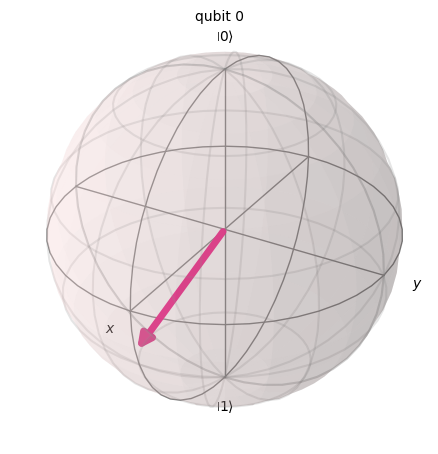

In [56]:
# ANTES(creado)
#aqc = QuantumCircuit(1)
#estado_antes = Statevector(qc)
#splot_bloch_multivector(estado_antes)
# DESPUES: Hadamard P
#qc.h(0)
#estado_despues = Statevector(qc)
#plot_bloch_multivector(estado_despues)

alpha, beta = 0.6, 0.8
qc = QuantumCircuit(1)
qc.initialize([alpha, beta], 0)

estado_antes = Statevector(qc)
pr0, pr1 = estado_antes.probabilities()

print(f"Pr(0) = (pr0:.2%)")
print(f"Pr(1) = (pr1:.2%)")
plot_bloch_multivector(Statevector(qc))

Pr(0) = (pr0:.2%)
Pr(1) = (pr1:.2%)


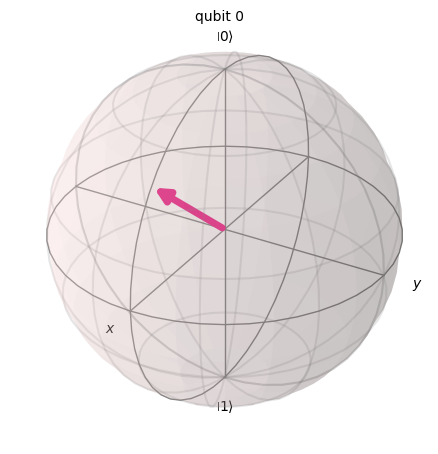

In [57]:
#!pip install qiskit qiskit-aer matplotlib pylatexenc
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import math

# ANTES(creado)
#aqc = QuantumCircuit(1)
#estado_antes = Statevector(qc)
#splot_bloch_multivector(estado_antes)
# DESPUES: Hadamard P
#qc.h(0)
#estado_despues = Statevector(qc)
#plot_bloch_multivector(estado_despues)
grad=25
rad = math.radians(grad)
alpha = math.cos(rad)
beta = math.sin(rad)
qc = QuantumCircuit(1)
qc.initialize([alpha, beta], 0)

estado_antes = Statevector(qc)
pr0, pr1 = estado_antes.probabilities()

print(f"Pr(0) = (pr0:.2%)")
print(f"Pr(1) = (pr1:.2%)")
plot_bloch_multivector(Statevector(qc))

In [58]:
#2.1 - Simulador interactivo de un qubit en la esfera de Bloch (optimizado)
!pip install ipywidgets matplotlib -q

import numpy as np
import matplotlib.pyplot as plt
from math import radians, sin, cos
import ipywidgets as widgets
from IPython.display import display

from google.colab import output
output.enable_custom_widget_manager()

# ---------- Esfera precalculada UNA sola vez (ya no se recalcula en cada frame) ----------
_u = np.linspace(0, 2 * np.pi, 30)
_v = np.linspace(0, np.pi, 15)
_xs = np.outer(np.cos(_u), np.sin(_v))
_ys = np.outer(np.sin(_u), np.sin(_v))
_zs = np.outer(np.ones(np.size(_u)), np.cos(_v))

# ---------- Figura creada UNA sola vez y reutilizada (evita crear/cerrar figuras en cada frame) ----------
plt.ioff()
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
out_plot = widgets.Output()  # aquí se refresca solo el dibujo, no todo el notebook


def dibujar_base():
    """Redibuja la esfera fija (rápido: pocos puntos, sin recalcular geometría)."""
    ax.cla()
    ax.plot_surface(_xs, _ys, _zs, alpha=0.15, edgecolor='gray',
                     linewidth=0.3, rstride=1, cstride=1)
    ax.plot([-1, 1], [0, 0], [0, 0], linewidth=1, color='gray')
    ax.plot([0, 0], [-1, 1], [0, 0], linewidth=1, color='gray')
    ax.plot([0, 0], [0, 0], [-1, 1], linewidth=1, color='gray')
    ax.scatter(0, 0, 1, s=60, color='black')
    ax.scatter(0, 0, -1, s=60, color='black')
    ax.text(0, 0, 1.15, '|0⟩', fontsize=13)
    ax.text(0, 0, -1.15, '|1⟩', fontsize=13)
    ax.text(1.1, 0, 0, 'X', fontsize=11)
    ax.text(0, 1.1, 0, 'Y', fontsize=11)
    ax.text(0, 0, 1.1, 'Z', fontsize=11)
    ax.set_xlim([-1.2, 1.2]); ax.set_ylim([-1.2, 1.2]); ax.set_zlim([-1.2, 1.2])
    ax.set_box_aspect([1, 1, 1])
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])


info = widgets.HTML()  # texto de estado, más rápido que print()


def actualizar(theta, phi):
    t, p = radians(theta), radians(phi)

    # |ψ⟩ = cos(θ/2)|0⟩ + e^(iφ)sin(θ/2)|1⟩  — calculado directo con NumPy, sin Qiskit
    alpha = cos(t / 2)
    beta = sin(t / 2) * cos(p) + 1j * sin(t / 2) * sin(p)
    pr0, pr1 = abs(alpha) ** 2, abs(beta) ** 2

    # Coordenadas del vector en la esfera de Bloch
    x, y, z = sin(t) * cos(p), sin(t) * sin(p), cos(t)

    dibujar_base()
    ax.quiver(0, 0, 0, x, y, z, color='red', linewidth=3, arrow_length_ratio=0.12)
    ax.set_title(f'Esfera de Bloch\nθ = {theta}°   φ = {phi}°', fontsize=13)

    with out_plot:
        out_plot.clear_output(wait=True)  # wait=True evita el parpadeo
        display(fig)

    info.value = (
        f"<b>Pr(0)</b> = {pr0:.2%} &nbsp;&nbsp; <b>Pr(1)</b> = {pr1:.2%}<br>"
        f"Estado: |ψ⟩ = {alpha:.3f}|0⟩ + ({beta.real:.3f}{beta.imag:+.3f}i)|1⟩"
    )


# SLIDERS
slider_theta = widgets.IntSlider(
    value=90, min=0, max=180, step=1, description='θ:',
    continuous_update=True, style={'description_width': '30px'},
    layout=widgets.Layout(width='500px')
)

slider_phi = widgets.IntSlider(
    value=0, min=0, max=360, step=1, description='φ:',
    continuous_update=True, style={'description_width': '30px'},
    layout=widgets.Layout(width='500px')
)

ui = widgets.VBox([slider_theta, slider_phi, info, out_plot])
enlace = widgets.interactive_output(actualizar, {'theta': slider_theta, 'phi': slider_phi})

display(ui)
actualizar(slider_theta.value, slider_phi.value)  # primer render

In [59]:
import numpy as np
# ===========================================================
# ACTIVIDAD 2.2
# ============================================================
# PARTE 1: PRODUCTOS INTERNOS
# ============================================================

# Estados básicos
ket0 = np.array([1, 0])
ket1 = np.array([0, 1])

# Estados de superposición
mas = np.array([1, 1]) / np.sqrt(2)
menos = np.array([1, -1]) / np.sqrt(2)

# Producto interno <0|1>
resultado_1 = np.vdot(ket0, ket1)

# Producto interno <0|+>
resultado_2 = np.vdot(ket0, mas)

# Producto interno <-|+>
resultado_3 = np.vdot(menos, mas)

print("⟨0|1⟩  =", resultado_1)
print("⟨0|+⟩  =", round(resultado_2, 3))
print("⟨-|+⟩  =", round(resultado_3, 3))


# ============================================================
# PARTE 2: PRODUCTO TENSORIAL
# ============================================================

# Combinar |+> con |+>
estado_conjunto = np.kron(mas, mas)

print("\n|+⟩ ⊗ |+⟩ =", np.round(estado_conjunto, 3))


# ============================================================
# VERIFICACIÓN DE NORMALIZACIÓN
# ============================================================

normalizacion = np.sum(np.abs(estado_conjunto) ** 2)

print("Normalización =", normalizacion)

⟨0|1⟩  = 0
⟨0|+⟩  = 0.707
⟨-|+⟩  = 0.0

|+⟩ ⊗ |+⟩ = [0.5 0.5 0.5 0.5]
Normalización = 0.9999999999999996


In [60]:
# ============================================================
# ACTIVIDAD 2.3 - COMPUERTAS CUÁNTICAS
# Computación Cuántica - LSCA2310
# ============================================================

# Importación de librerías
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt


# ============================================================
# FUNCIÓN PARA MOSTRAR EL ESTADO INICIAL Y FINAL
# ============================================================

def mostrar_compuerta(nombre, circuito_inicial, circuito_final):

    # Obtener el vector de estado inicial
    estado_inicial = Statevector(circuito_inicial)

    # Obtener el vector de estado final
    estado_final = Statevector(circuito_final)

    print("=" * 60)
    print(f"COMPUERTA {nombre}")
    print("=" * 60)

    print("\nEstado inicial:")
    print(estado_inicial)

    print("\nEstado final:")
    print(estado_final)

    # Mostrar esfera de Bloch del estado inicial
    print("\nEsfera de Bloch - Estado inicial")
    display(plot_bloch_multivector(estado_inicial))

    # Mostrar esfera de Bloch del estado final
    print("\nEsfera de Bloch - Estado final")
    display(plot_bloch_multivector(estado_final))

COMPUERTA X

Estado inicial:
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))

Estado final:
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))

Esfera de Bloch - Estado inicial


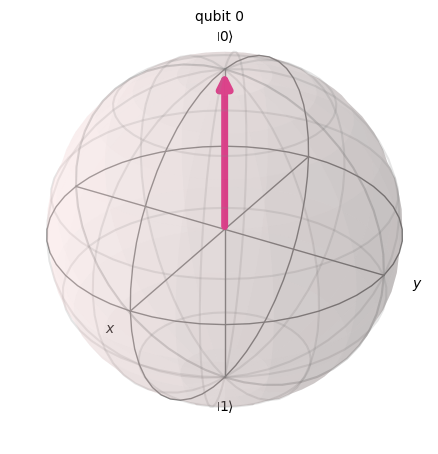


Esfera de Bloch - Estado final


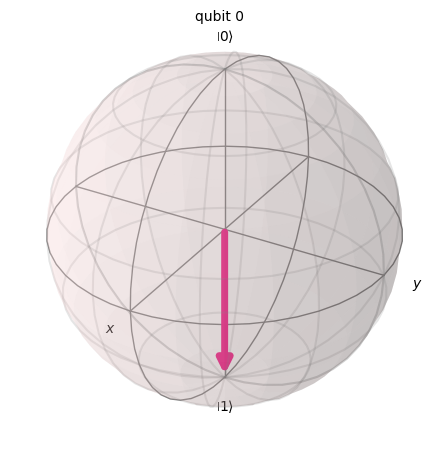

In [61]:
# ============================================================
# COMPUERTA X
# |0> -> |1>
# ============================================================

# Estado inicial |0>
qc_inicial = QuantumCircuit(1)

# Circuito donde se aplica X
qc_x = QuantumCircuit(1)
qc_x.x(0)

# Mostrar resultados
mostrar_compuerta("X", qc_inicial, qc_x)

COMPUERTA Y

Estado inicial:
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))

Estado final:
Statevector([0.+0.j, 0.+1.j],
            dims=(2,))

Esfera de Bloch - Estado inicial


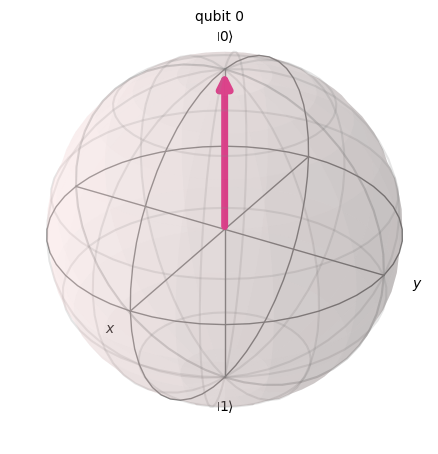


Esfera de Bloch - Estado final


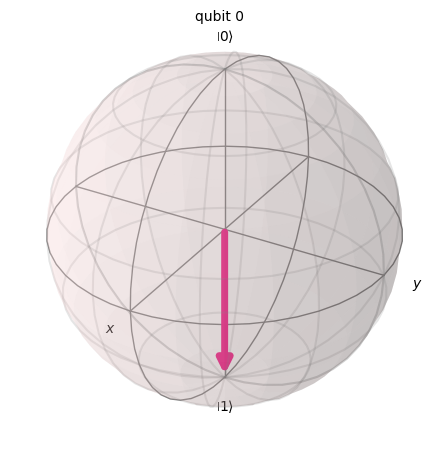

In [62]:
# ============================================================
# COMPUERTA Y
# |0> -> i|1>
# ============================================================

# Estado inicial |0>
qc_inicial = QuantumCircuit(1)

# Circuito donde se aplica Y
qc_y = QuantumCircuit(1)
qc_y.y(0)

# Mostrar resultados
mostrar_compuerta("Y", qc_inicial, qc_y)

COMPUERTA Z

Estado inicial:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

Estado final:
Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))

Esfera de Bloch - Estado inicial


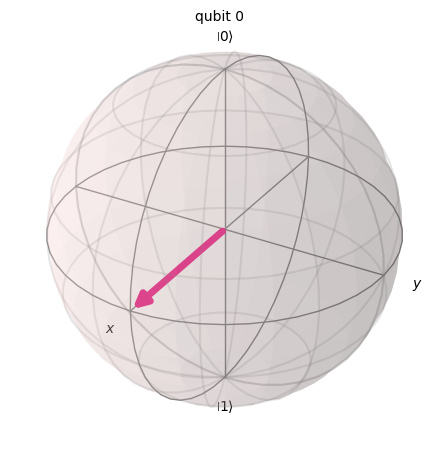


Esfera de Bloch - Estado final


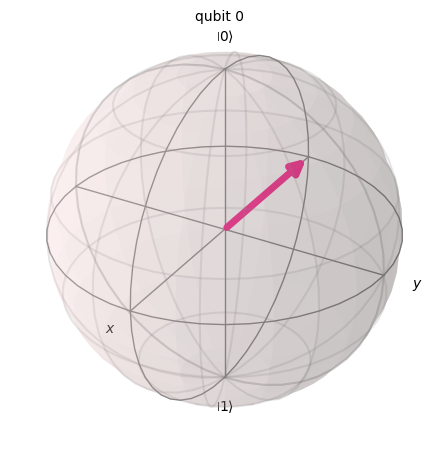

In [63]:
# ============================================================
# COMPUERTA Z
# |+> -> |->
# ============================================================

# Crear |+>
qc_inicial = QuantumCircuit(1)
qc_inicial.h(0)

# Crear el circuito final:
# Primero H para obtener |+>
# Después Z para cambiar la fase
qc_z = QuantumCircuit(1)
qc_z.h(0)
qc_z.z(0)

# Mostrar resultados
mostrar_compuerta("Z", qc_inicial, qc_z)

COMPUERTA H

Estado inicial:
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))

Estado final:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

Esfera de Bloch - Estado inicial


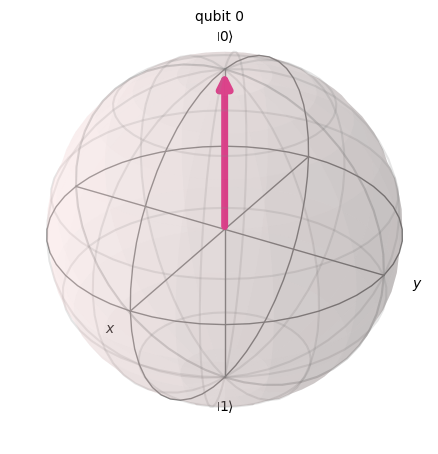


Esfera de Bloch - Estado final


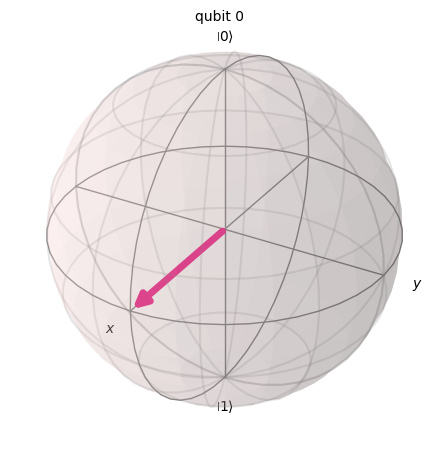

In [64]:
# ============================================================
# COMPUERTA H
# |0> -> |+>
# ============================================================

# Estado inicial |0>
qc_inicial = QuantumCircuit(1)

# Aplicar Hadamard
qc_h = QuantumCircuit(1)
qc_h.h(0)

# Mostrar resultados
mostrar_compuerta("H", qc_inicial, qc_h)

COMPUERTA S

Estado inicial:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

Estado final:
Statevector([0.70710678+0.j        , 0.        +0.70710678j],
            dims=(2,))

Esfera de Bloch - Estado inicial


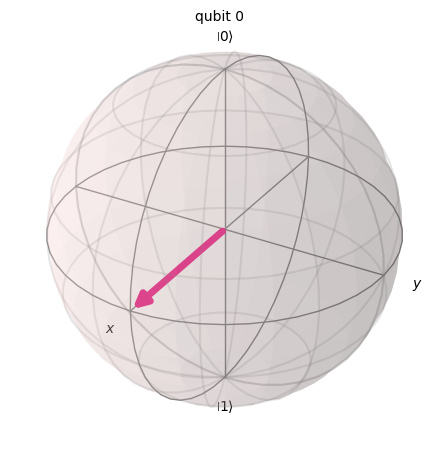


Esfera de Bloch - Estado final


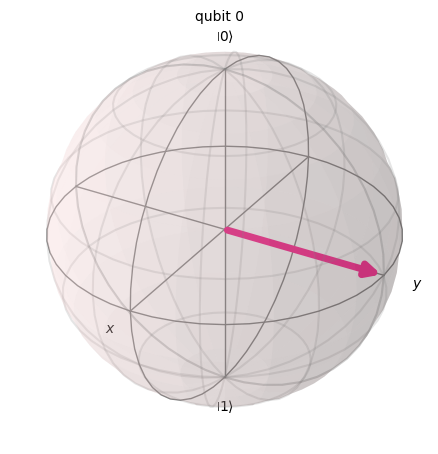

In [65]:
# ============================================================
# COMPUERTA S
# |+> -> (|0> + i|1>) / sqrt(2)
# ============================================================

# Crear |+>
qc_inicial = QuantumCircuit(1)
qc_inicial.h(0)

# Aplicar H y después S
qc_s = QuantumCircuit(1)
qc_s.h(0)
qc_s.s(0)

# Mostrar resultados
mostrar_compuerta("S", qc_inicial, qc_s)

COMPUERTA T

Estado inicial:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

Estado final:
Statevector([0.70710678+0.j , 0.5       +0.5j],
            dims=(2,))

Esfera de Bloch - Estado inicial


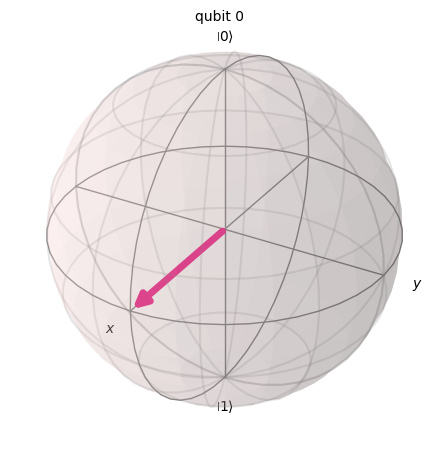


Esfera de Bloch - Estado final


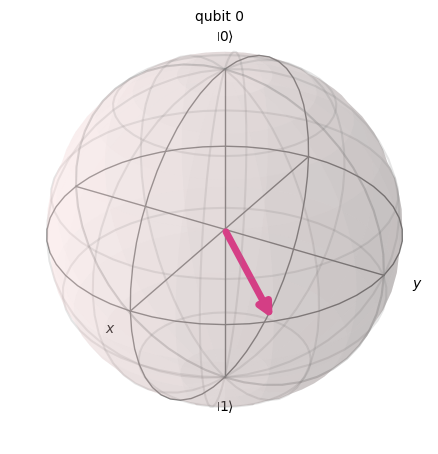

In [66]:
# ============================================================
# COMPUERTA T
# |+> -> (|0> + e^(i*pi/4)|1>) / sqrt(2)
# ============================================================

# Crear |+>
qc_inicial = QuantumCircuit(1)
qc_inicial.h(0)

# Aplicar H y después T
qc_t = QuantumCircuit(1)
qc_t.h(0)
qc_t.t(0)

# Mostrar resultados
mostrar_compuerta("T", qc_inicial, qc_t)

In [77]:
!pip install -q qiskit
!pip install pylatexenc
!pip install qiskit qiskit-aer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 74.3 MB/s eta 0:00:00


In [86]:
# Instalar librería necesaria
!pip install pylatexenc

# Importar Qiskit
from qiskit import QuantumCircuit

# Crear el circuito de Bell
qc_bell = QuantumCircuit(2)
qc_bell.h(0)        # Hadamard en qubit 0
qc_bell.cx(0, 1)    # CNOT entre qubit 0 y 1


In [89]:
qc_bell.draw(output='text')

┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘